# Лабораторная работа №3

In [189]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Выбор датасетов: четный номер -> жилье в калифорнии

In [190]:
np.random.seed(42)
data = pd.read_csv("data/california_housing_train.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


## Получите и визуализируйте статистику по датасету (включая количество, среднее значение, стандартное отклонение, минимум, максимум и различные квантили).

In [191]:
statistics = data.describe()
print(statistics)

          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1462.000000   
50%     -118.490000     34.250000           29.000000   2127.000000   
75%     -118.000000     37.720000           37.000000   3151.250000   
max     -114.310000     41.950000           52.000000  37937.000000   

       total_bedrooms    population    households  median_income  \
count    17000.000000  17000.000000  17000.000000   17000.000000   
mean       539.410824   1429.573941    501.221941       3.883578   
std        421.499452   1147.852959    384.520841       1.908157   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

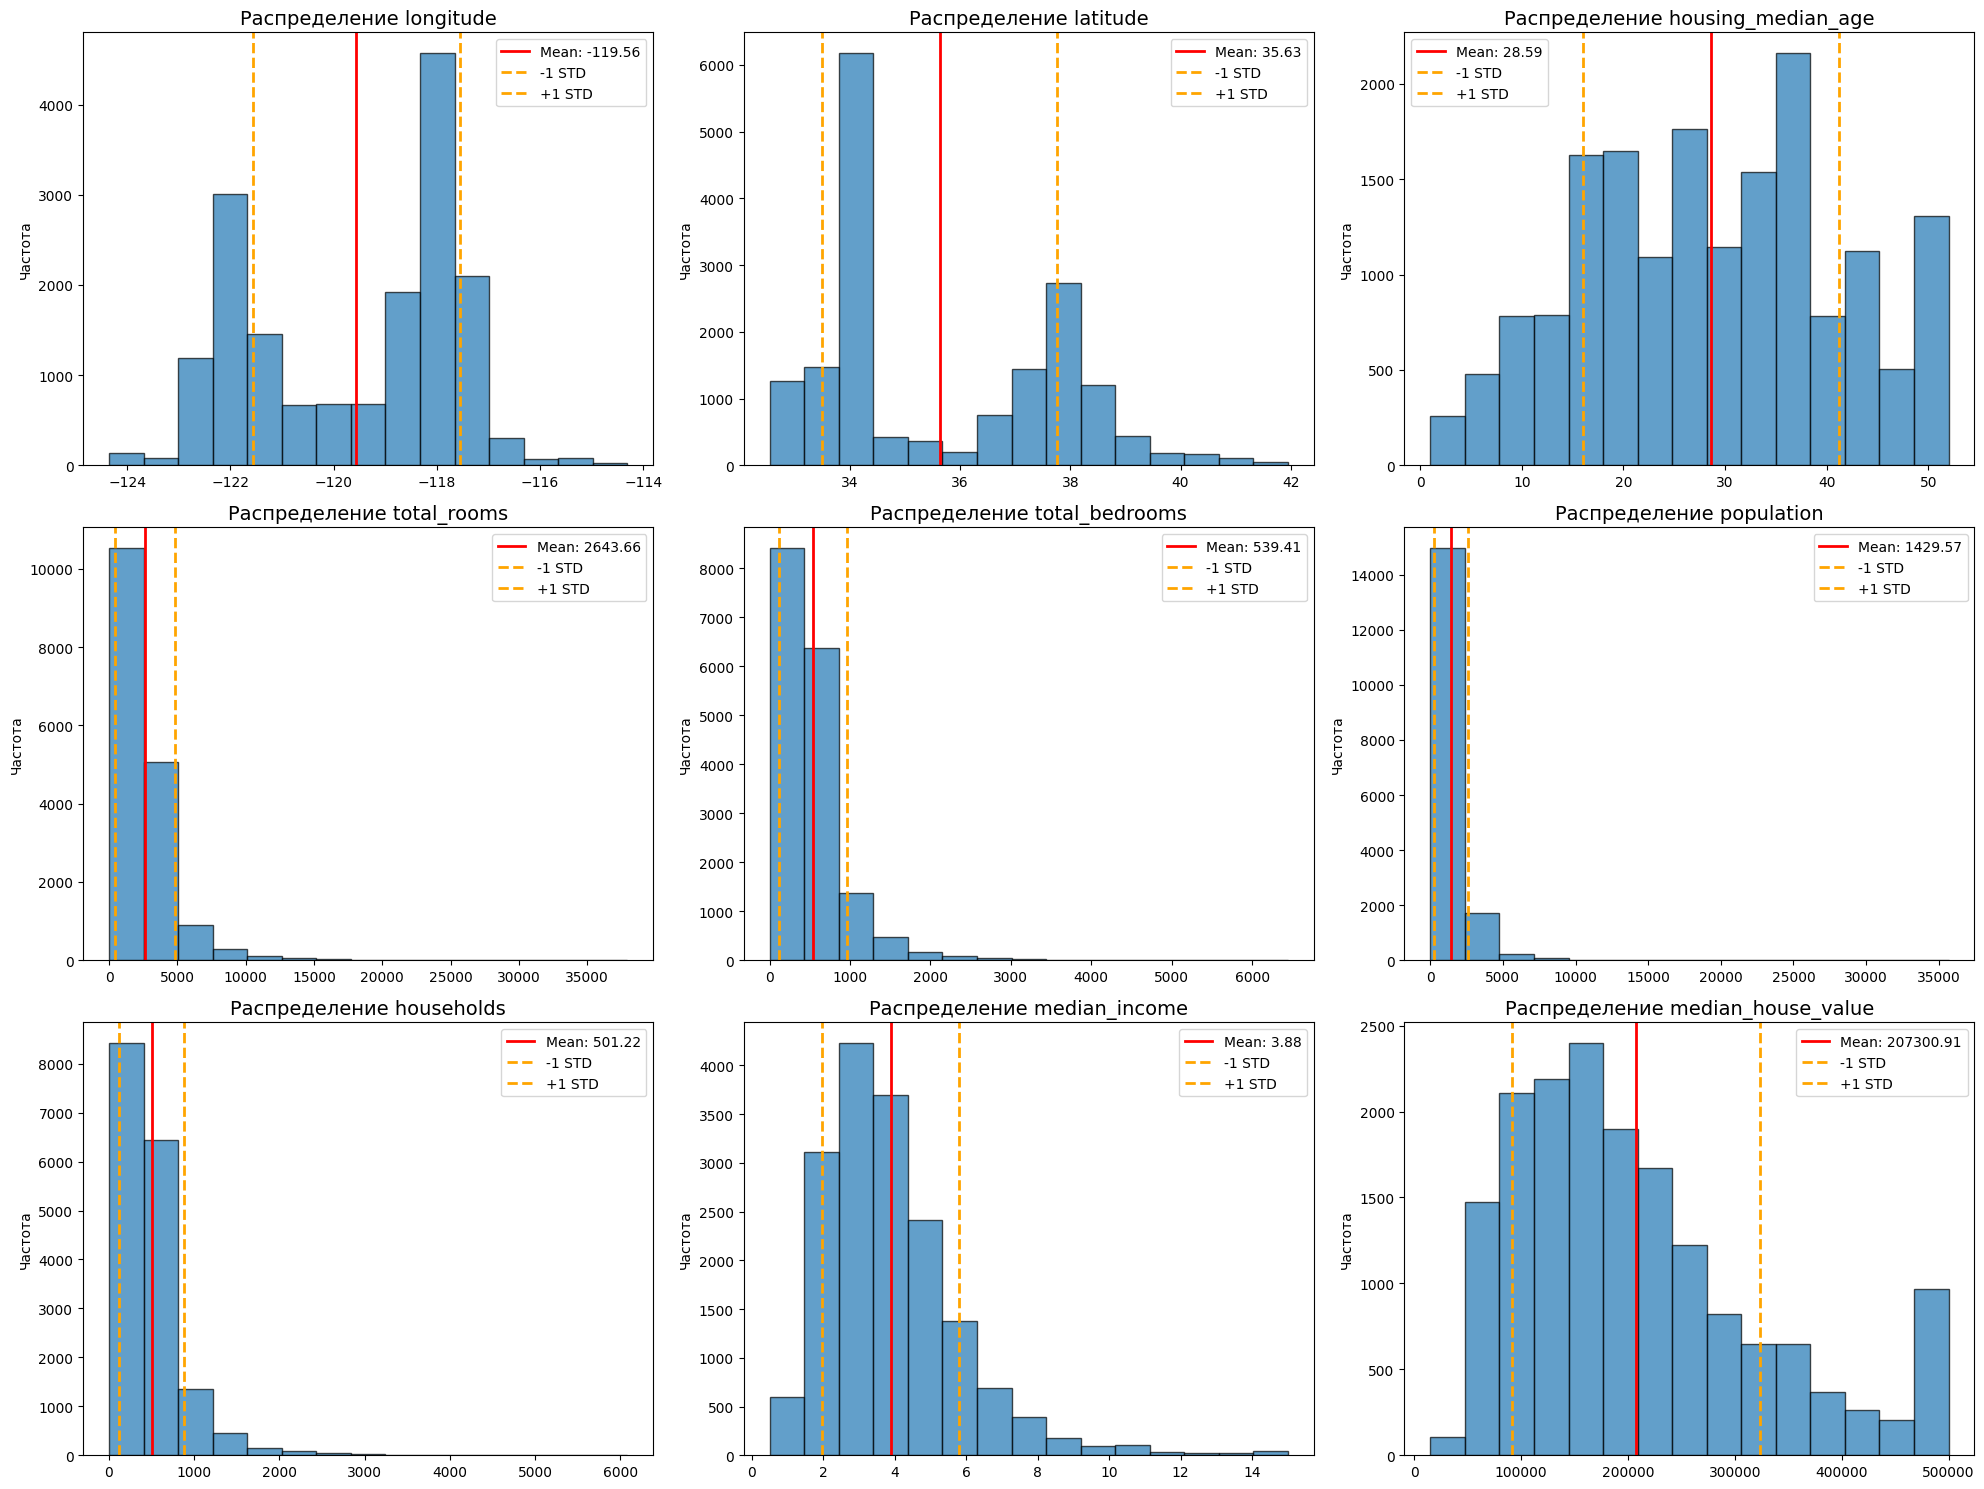

In [192]:
num_rows = len(data)
bins_count = 1 + int(math.log2(num_rows))

columns = data.columns
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel() 

for i, col in enumerate(columns):
    ax = axes[i]
    
    counts, bins, patches = ax.hist(data[col], bins=bins_count, color='#1f77b4', edgecolor='black', alpha=0.7)
    
    mu = data[col].mean()
    sigma = data[col].std()
    
    ax.axvline(mu, color='red', linestyle='solid', linewidth=2, label=f'Mean: {mu:.2f}')
    ax.axvline(mu - sigma, color='orange', linestyle='dashed', linewidth=2, label=f'-1 STD')
    ax.axvline(mu + sigma, color='orange', linestyle='dashed', linewidth=2, label=f'+1 STD')
    
    ax.set_title(f'Распределение {col}', fontsize=14)
    ax.set_ylabel('Частота')
    ax.legend()

plt.tight_layout()
plt.show()

In [193]:
print("Количество строк:", len(data))
print("Количество столбцов:", data.shape[1])

print("\nСредние значения:")
print(data.mean())

print("\nСтандартные отклонения:")
print(data.std())

print("\nМинимумы:")
print(data.min())

print("\nМаксимумы:")
print(data.max())

print("\nКвантили (25%, 50%, 75%):")
print(data.quantile([0.25, 0.5, 0.75]))

Количество строк: 17000
Количество столбцов: 9

Средние значения:
longitude               -119.562108
latitude                  35.625225
housing_median_age        28.589353
total_rooms             2643.664412
total_bedrooms           539.410824
population              1429.573941
households               501.221941
median_income              3.883578
median_house_value    207300.912353
dtype: float64

Стандартные отклонения:
longitude                  2.005166
latitude                   2.137340
housing_median_age        12.586937
total_rooms             2179.947071
total_bedrooms           421.499452
population              1147.852959
households               384.520841
median_income              1.908157
median_house_value    115983.764387
dtype: float64

Минимумы:
longitude              -124.3500
latitude                 32.5400
housing_median_age        1.0000
total_rooms               2.0000
total_bedrooms            1.0000
population                3.0000
households            

## Проведите предварительную обработку данных, включая обработку отсутствующих значений, кодирование категориальных признаков и нормировка.

In [194]:
if not data.isna().any().any():
    print("В данных нет пустых значений")
else:
    data.dropna(inplace=True)
    print("Пустые значения удалены")

data = data.fillna(data.median())

numerical_features = data.select_dtypes(include=['number']).columns.drop("median_house_value")
categorical_features = data.select_dtypes(include=['object']).columns

print(f"Числовые признаки: {list(numerical_features)}")

if len(categorical_features) > 0:
    print(f"Кодируем категориальные признаки: {list(categorical_features)}")
    data = pd.get_dummies(data, columns=categorical_features, drop_first=True)
else:
    print("Категориальных признаков нет")

В данных нет пустых значений
Числовые признаки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Категориальных признаков нет


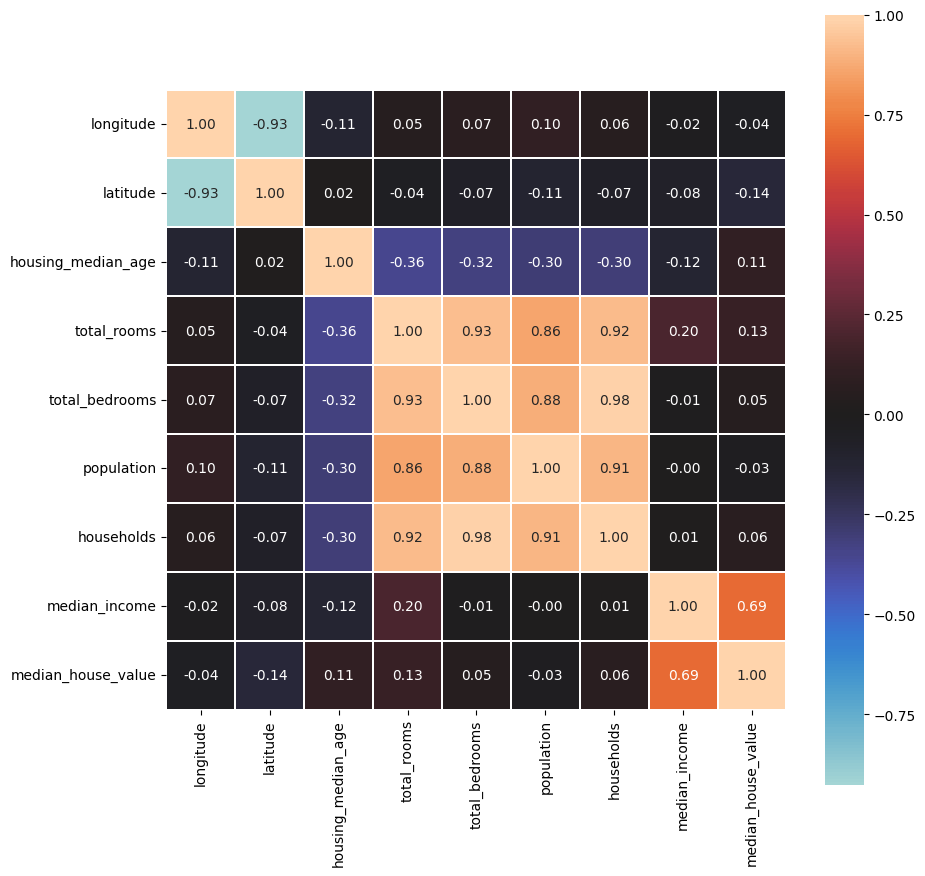

In [195]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True, fmt=".2f", center=0,
            square=True, linewidths=0.1)
plt.show()

In [196]:
data_crop = data.copy()

la_coords = np.array([34.05, -118.24])
sf_coords = np.array([37.77, -122.41])

coords = data_crop[['latitude', 'longitude']].values

dist_to_la = np.sqrt(np.sum((coords - la_coords)**2, axis=1))
dist_to_sf = np.sqrt(np.sum((coords - sf_coords)**2, axis=1))

min_dist = np.minimum(dist_to_la, dist_to_sf)

data_crop['dist_to_city'] = np.minimum(dist_to_la, dist_to_sf)
data_crop["rooms_per_household"] = data_crop["total_rooms"] / data_crop["households"]
data_crop["bedrooms_per_room"] = data_crop["total_bedrooms"] / data_crop["total_rooms"]
data_crop["population_per_household"] = data_crop["population"] / data_crop["households"]

cols_to_drop = ['total_rooms', 'total_bedrooms', 'population', 'households', 'latitude', 'longitude']
data_crop = data_crop.drop(cols_to_drop, axis=1)

numerical_features = [col for col in data_crop.columns if col != "median_house_value"]

print("Итоговые признаки:", list(data_crop.columns))

Итоговые признаки: ['housing_median_age', 'median_income', 'median_house_value', 'dist_to_city', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


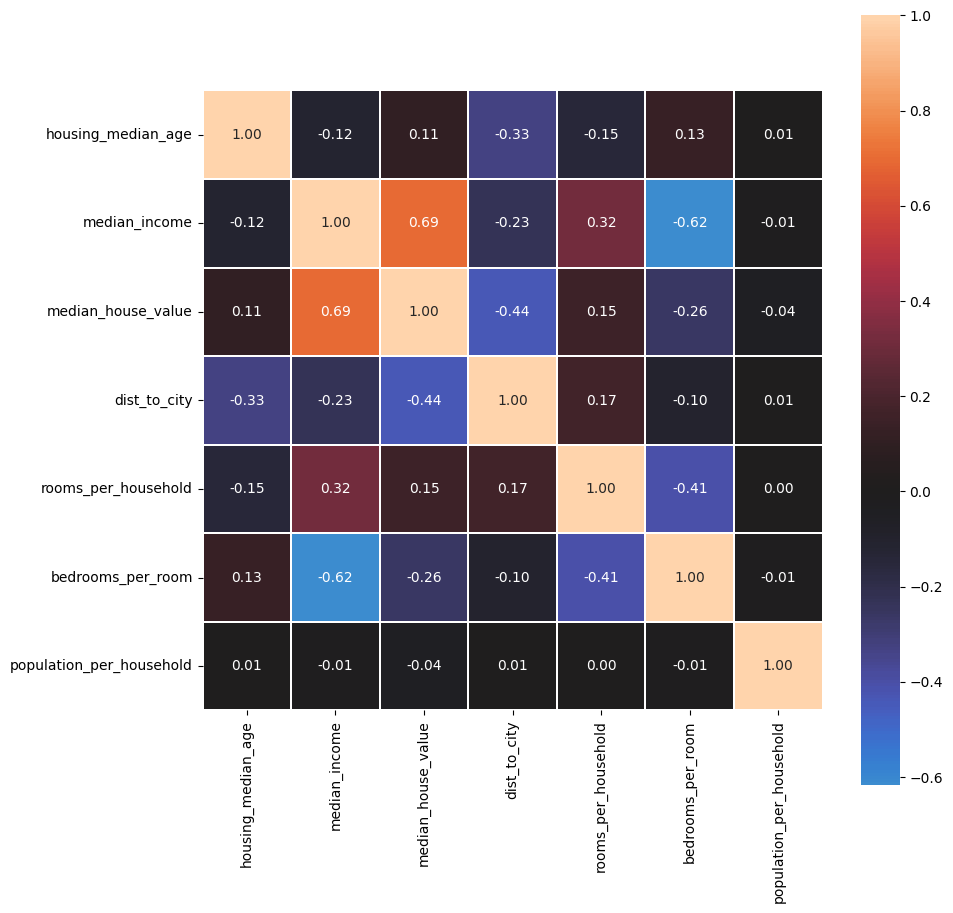

In [197]:
plt.figure(figsize=(10, 10))
sns.heatmap(data_crop.corr(), annot=True, fmt=".2f", center=0,
            square=True, linewidths=0.1)
plt.show()

In [199]:
n_data = data_crop.copy()

for col in data_crop:
    min_v = data_crop[col].min()
    max_v = data_crop[col].max()
    if min_v == max_v:
        continue
    n_data[col] = (data_crop[col] - min_v) / (max_v - min_v)

## Разделите данные на обучающий и тестовый наборы данных.

In [200]:
data_ready = n_data.copy()

data_shuffled = data_ready.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.8 * len(data_shuffled))

train_data = data_shuffled.iloc[:train_size].copy()
test_data = data_shuffled.iloc[train_size:].copy()

print("Размер train:", train_data.shape)
print("Размер test:", test_data.shape)

Размер train: (13600, 7)
Размер test: (3400, 7)


In [201]:
y_train = train_data["median_house_value"].values
y_test  = test_data["median_house_value"].values

X_train_full = train_data[numerical_features].values
X_test_full  = test_data[numerical_features].values

X_train_full.shape, X_test_full.shape

((13600, 6), (3400, 6))

## Реализуйте линейную регрессию с использованием метода наименьших квадратов без использования сторонних библиотек, кроме NumPy и Pandas (для использования коэффициентов использовать библиотеки тоже нельзя). Использовать минимизацию суммы квадратов разностей между фактическими и предсказанными значениями для нахождения оптимальных коэффициентов.

In [202]:
def add_bias(X):
    n_samples = X.shape[0]
    ones = np.ones((n_samples, 1))
    return np.hstack([ones, X])

def fit_linear_regression(X, y):
    XTX = X.T @ X
    XTy = X.T @ y
    theta = np.linalg.inv(XTX) @ XTy
    return theta

def predict(X, theta):
    return X @ theta

def r2_score_manual(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

## Постройте три модели с различными наборами признаков.

In [203]:
features_model1 = ["median_income"]

X_train_m1 = train_data[features_model1].values
X_test_m1  = test_data[features_model1].values

X_train_m1_bias = add_bias(X_train_m1)
X_test_m1_bias  = add_bias(X_test_m1)

theta_m1 = fit_linear_regression(X_train_m1_bias, y_train)
y_pred_m1 = predict(X_test_m1_bias, theta_m1)

r2_m1 = r2_score_manual(y_test, y_pred_m1)
print("Модель 1 (median_income), R^2:", r2_m1)
print("Коэффициенты (theta):", theta_m1)

Модель 1 (median_income), R^2: 0.46581636306048935
Коэффициенты (theta): [0.10161118 1.26666229]


In [204]:
features_model2 = ["median_income", "housing_median_age", "dist_to_city"]

X_train_m2 = train_data[features_model2].values
X_test_m2  = test_data[features_model2].values

X_train_m2_bias = add_bias(X_train_m2)
X_test_m2_bias  = add_bias(X_test_m2)

theta_m2 = fit_linear_regression(X_train_m2_bias, y_train)
y_pred_m2 = predict(X_test_m2_bias, theta_m2)

r2_m2 = r2_score_manual(y_test, y_pred_m2)
print("Модель 2 (income + age + rooms), R^2:", r2_m2)
print("Коэффициенты (theta):", theta_m2)

Модель 2 (income + age + rooms), R^2: 0.5527333198471955
Коэффициенты (theta): [ 0.14073854  1.17511457  0.09199607 -0.34834633]


In [205]:
features_model3 = numerical_features

X_train_m3 = train_data[features_model3].values
X_test_m3  = test_data[features_model3].values

X_train_m3_bias = add_bias(X_train_m3)
X_test_m3_bias  = add_bias(X_test_m3)

theta_m3 = fit_linear_regression(X_train_m3_bias, y_train)
y_pred_m3 = predict(X_test_m3_bias, theta_m3)

r2_m3 = r2_score_manual(y_test, y_pred_m3)
print("Модель 3 (все признаки), R^2:", r2_m3)
print("Коэффициенты (theta):", theta_m3)

Модель 3 (все признаки), R^2: 0.573628758441778
Коэффициенты (theta): [-0.02297516  0.10036967  1.39614491 -0.28494032  0.31841962  0.70567454
 -0.74789366]


In [206]:
results = pd.DataFrame({
    "Модель": ["Модель 1 (Income)", "Модель 2 (3 признака)", "Модель 3 (Все признаки)"],
    "R2 Score": [r2_m1, r2_m2, r2_m3]
})

print("Сравнение результатов:")
print(results)

best_model_idx = results["R2 Score"].idxmax()
best_model_name = results.loc[best_model_idx, "Модель"]
best_r2 = results.loc[best_model_idx, "R2 Score"]

print(f"\nЛучшая модель: {best_model_name} с R2 = {best_r2:.5f}")

Сравнение результатов:
                    Модель  R2 Score
0        Модель 1 (Income)  0.465816
1    Модель 2 (3 признака)  0.552733
2  Модель 3 (Все признаки)  0.573629

Лучшая модель: Модель 3 (Все признаки) с R2 = 0.57363
